# Sentiment Analysis Pipeline for Nuclear/Atomic Energy Discourse

This notebook executes the complete sentiment analysis pipeline, comparing multiple approaches:
- Manual annotation (ground truth)
- Dictionary-based methods (VADER, HIV4)
- Transformer-based models (RoBERTa-SieBERT, RoBERTa-Twitter)

**Note**: Steps 1-2 have already been completed. The annotated sample (`200_samples.csv`) is fixed and should not be regenerated to preserve consistency with manual annotations.

## Setup: Import Required Libraries

In [1]:
import os
import pandas as pd

# Set working directory to kapitel_9 for script execution
os.chdir('kapitel_8')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\janal\OneDrive\Desktop\kapitel_8\kapitel_8


## Step 1: Extract Context Windows (Already Completed)

This step extracts sentences containing "nuclear" or "atom" keywords along with ±1 sentence of context from the full article corpus. The output file `extracted_nuclear_atom_contexts_fin.csv` already exists.

**What it does**:
- Uses NLTK sentence tokenization
- Regex pattern: `\b(nuclear|atom\w*)\b` (case-insensitive)
- Extracts ±1 sentence window around each keyword match
- Merges overlapping context windows (expands window if adjacent sentences also contain keywords)
- Removes duplicate context blocks across the entire dataset (not just per article)

**Uncomment to re-run** (not recommended unless source corpus changes):

In [ ]:
# %run sentence_context.py artikel_korpus_fin_updated.csv

## Step 2: Generate Sample and Manual Annotation (Already Completed)

This step randomly samples 200 contexts for manual annotation. **DO NOT re-run** as it would change the sample and invalidate existing annotations.

**What it does**:
- Takes first occurrence per article ID
- Random sample of 200 contexts (random_state=42 for reproducibility)
- Output: `200_samples.csv` (fixed dataset)

The manual annotations are stored in `annotation_final.csv` and dictionary-based results in `dictionary_results_200.csv`.

In [ ]:
# %run generate_samples.py extracted_nuclear_atom_contexts_fin.csv 200_samples.csv  # DO NOT RUN - sample is fixed

### Verify Input Data

Let's verify that the required input files exist and check their sizes:

In [2]:
# Check input files
files_to_check = [
    '200_samples.csv',
    'annotation_final.csv',
    'dictionary_results_200.csv'
]

print("Input files status:\n")
for file in files_to_check:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';' if file != 'dictionary_results_200.csv' else ',', encoding='latin-1')
        print(f"{file}: {len(df)} rows")
    else:
        print(f"{file}: NOT FOUND")

Input files status:

200_samples.csv: 200 rows
annotation_final.csv: 999 rows
dictionary_results_200.csv: 200 rows


## Step 3: RoBERTa-SieBERT Sentiment Analysis

Run sentiment analysis using the RoBERTa-SieBERT model (`siebert/sentiment-roberta-large-english`).

**Prerequisites**:
- Requires PyTorch to be installed
- This notebook uses CPU-only version of PyTorch. Install with: `pip install torch --index-url https://download.pytorch.org/whl/cpu`
- For GPU support (faster but larger download ~2-3GB), use: `pip install torch`
- Note that the Jupyter kernal will need to be restarted after PyTorch install.

**What it does**:
- Tokenizes text into sentences using NLTK
- Scores each sentence with RoBERTa-SieBERT (batch_size=16)
- Returns probabilities for positive/negative classes
- Aggregates sentence scores to document-level polarity: `(Σp_pos - Σp_neg) / (Σp_pos + Σp_neg)`
- Saves checkpoints every 5000 sentences for interruption recovery

**Outputs**: 
- `sentence_sentiment_siebert.csv` (sentence-level scores)
- `doc_polarity_results_siebert.csv` (document-level polarity)
- `RoBERTa_SieBERT_Polarity.png` (histogram)

Running RoBERTa-SieBERT sentiment analysis...



c:\Users\janal\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading CSV
CSV loaded. Columns: ['ID', 'extracted_text']
Loading model


Device set to use cpu
c:\Users\janal\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Model ready. Labels: {'negative': 0, 'positive': 1}
Scoring sentences


Documents: 100%|██████████| 200/200 [04:05<00:00,  1.23s/it]


Scored 601 sentences from 200 documents.
Doc-level polarity stats: mean=+0.064, sd=0.679, min=-0.998, max=+0.998


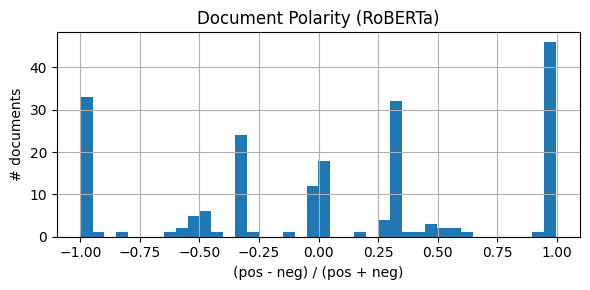

Sentence results  C:\Users\janal\OneDrive\Desktop\kapitel_8\kapitel_8\sentence_sentiment_siebert.csv
Document polarity  C:\Users\janal\OneDrive\Desktop\kapitel_8\kapitel_8\doc_polarity_results_siebert.csv


In [3]:
print("Running RoBERTa-SieBERT sentiment analysis...\n")
%run roberta_alpha_samples_polarity_siebert.py

## Step 4: RoBERTa-Twitter Sentiment Analysis

Run sentiment analysis using the RoBERTa-Twitter model (`cardiffnlp/twitter-roberta-base-sentiment-latest`).

**Prerequisites**:
- Requires PyTorch (same as Step 3)

**What it does**:
- Same pipeline as RoBERTa-SieBERT but with a Twitter-trained model
- Twitter model may be more sensitive to informal/emotive language
- Uses identical aggregation formula and checkpointing

**Outputs**: 
- `sentence_sentiment_twitter.csv` (sentence-level scores)
- `doc_polarity_results_twitter.csv` (document-level polarity)
- `RoBERTa_Twitter_Polarity.png` (histogram)

Running RoBERTa-Twitter sentiment analysis...

Reading CSV
CSV loaded. Columns: ['ID', 'extracted_text']
Loading model


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
c:\Users\janal\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` o

Model ready. Labels: {'negative': 0, 'neutral': 1, 'positive': 2}
Scoring sentences


Documents: 100%|██████████| 200/200 [01:42<00:00,  1.94it/s]


Scored 601 sentences from 200 documents.
Doc-level polarity stats: mean=-0.323, sd=0.627, min=-0.978, max=+0.994


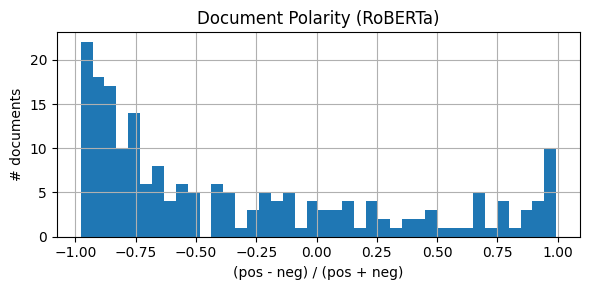

Sentence results  C:\Users\janal\OneDrive\Desktop\kapitel_8\kapitel_8\sentence_sentiment_twitter.csv
Document polarity  C:\Users\janal\OneDrive\Desktop\kapitel_8\kapitel_8\doc_polarity_results_twitter.csv


In [4]:
print("Running RoBERTa-Twitter sentiment analysis...\n")
%run roberta_alpha_samples_polarity_twitter.py

## Step 5: Merge All Sentiment Results

Combine results from all sentiment analysis approaches into a single dataset for comparison.

**What it does**:
- Merges four CSV files on the common ID column:
  - `annotation_final.csv` -> `sentiment_final` (ground truth)
  - `dictionary_results_200.csv` -> `HIV4_Polarity`, `VADER_Compound`
  - `doc_polarity_results_siebert.csv` -> `polarity_siebert`
  - `doc_polarity_results_twitter.csv` -> `polarity_twitter`

**Output**: `merged_polarity.csv` (unified dataset with all sentiment scores)

In [5]:
print("Merging all sentiment results...\n")
%run merge_polarity.py

Merging all sentiment results...

Saved merged file to merged_polarity.csv (rows: 200)


### Preview Merged Results

Preview the first 5 rows of all columns of the merged dataset.

In [6]:
merged_df = pd.read_csv('merged_polarity.csv')
print(f"Merged dataset: {len(merged_df)} documents\n")
print("Columns:", list(merged_df.columns))
print("\nFirst 5 rows:")
merged_df.head()

Merged dataset: 200 documents

Columns: ['ID', 'sentiment_final', 'HIV4_Polarity', 'VADER_Compound', 'polarity_siebert', 'polarity_twitter']

First 5 rows:


,ID,sentiment_final,HIV4_Polarity,VADER_Compound,polarity_siebert,polarity_twitter
0,8915.0,neutral,0.000000,0.2960,-0.006004,-0.693110
1,628.0,negative,-0.111111,-0.7650,-0.005982,-0.978287
2,1279.0,negative,0.200000,-0.6688,-0.996334,-0.969529
3,5129.0,neutral,0.500000,-0.5719,-0.995952,-0.915414
4,8568.0,neutral,1.000000,-0.3400,0.327205,-0.130507


## Step 6: Evaluate Model Performance

Calculate precision, recall, F1-scores, and generate confusion matrices for each sentiment analysis method.

**What it does**:
- Converts continuous polarity scores to categorical labels using thresholds:
  - `score > 0.25` → positive
  - `score < -0.25` → negative
  - `-0.25 ≤ score ≤ 0.25` → neutral
- Compares predictions against manual annotations (ground truth)
- Computes classification metrics for each method: VADER, HIV4, RoBERTa-SieBERT, RoBERTa-Twitter
- Generates confusion matrix heatmaps

**Outputs**: 
- Classification reports (precision, recall, F1-score per class)
- `confusion_matrix_VADER.png`
- `confusion_matrix_HIV4.png`
- `confusion_matrix_RoBERTa-SieBERT.png`
- `confusion_matrix_RoBERTa-Twitter.png`

In [7]:
print("Evaluating model performance...\n")
%run precision_recall.py

Evaluating model performance...


=== VADER ===
              precision    recall  f1-score   support

    positive       0.22      0.59      0.32        27
     neutral       0.39      0.18      0.24        67
    negative       0.72      0.64      0.68       106

    accuracy                           0.48       200
   macro avg       0.44      0.47      0.41       200
weighted avg       0.54      0.48      0.48       200

Saved confusion_matrix_VADER.png

=== RoBERTa-SieBERT ===
              precision    recall  f1-score   support

    positive       0.24      0.81      0.37        27
     neutral       0.31      0.15      0.20        67
    negative       0.77      0.55      0.64       106

    accuracy                           0.45       200
   macro avg       0.44      0.50      0.40       200
weighted avg       0.55      0.45      0.46       200

Saved confusion_matrix_RoBERTa-SieBERT.png

=== RoBERTa-Twitter ===
              precision    recall  f1-score   support

    posit